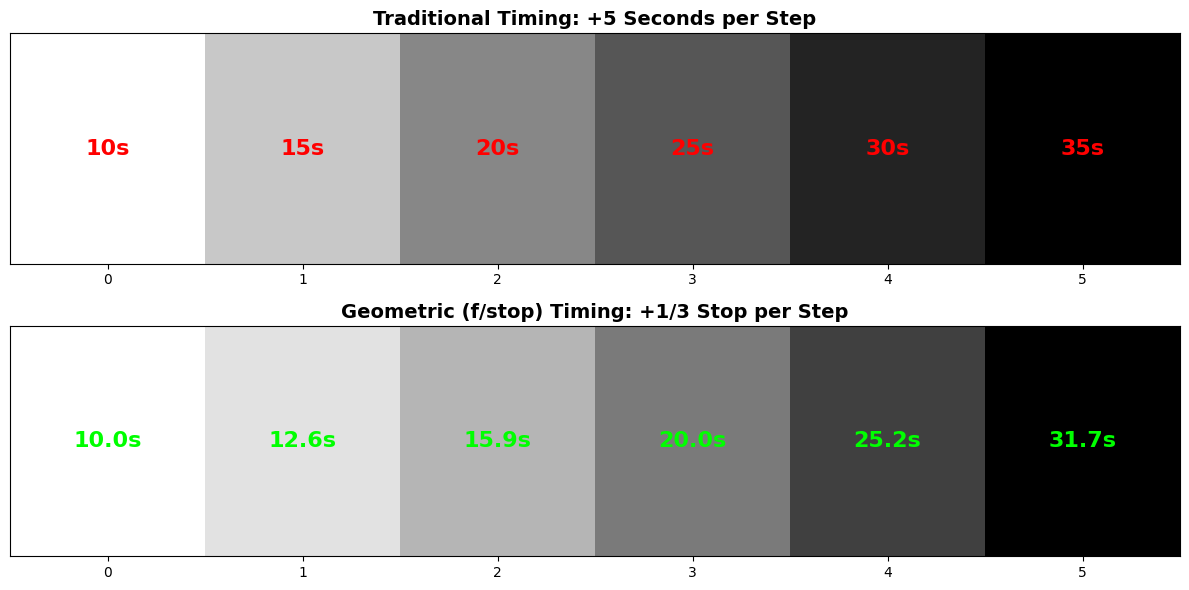

--- MATHEMATICAL ANALYSIS ---
Look at the percentage increase of light between the final two steps:

Arithmetic jump from 30s to 35s: Only 16.7% more light. (Visually invisible)
Geometric jump from 25.2s to 31.7s: 26.0% more light. (A perfect, even step)


In [1]:
# ⏱️ Interactive Simulator: Arithmetic vs. Geometric Test Strips

import numpy as np
import matplotlib.pyplot as plt

def simulate_test_strips():
    """
    Simulates the visual difference between a traditional 5-second interval test strip
    and a modern 1/3 f-stop interval test strip.
    """
    # 1. Arithmetic Timing (Adding 5 seconds each step)
    arithmetic_times = np.array([10, 15, 20, 25, 30, 35])
    
    # 2. Geometric / f-stop Timing (Adding 1/3 of a stop each step)
    # Formula: Next Time = Base Time * (2 ^ (1/3))
    base_time = 10
    geometric_times = base_time * (2 ** (np.arange(6) / 3))
    
    # --- Photographic Paper Simulation ---
    # Paper density roughly follows the log of exposure. 
    # We will convert the raw seconds into a "Gray Value" (0 = White, 1 = Black)
    def calc_density(times):
        # Simplified characteristic curve simulation
        density = np.log10(times) / np.log10(50) 
        return np.clip(density, 0, 1)

    arithmetic_density = calc_density(arithmetic_times)
    geometric_density = calc_density(geometric_times)

    # --- Visualization ---
    fig, axes = plt.subplots(2, 1, figsize=(12, 6))
    
    # Draw Arithmetic Strip
    axes[0].imshow([arithmetic_density], cmap='Greys', aspect='auto')
    axes[0].set_title("Traditional Timing: +5 Seconds per Step", fontsize=14, fontweight='bold')
    axes[0].set_yticks([])
    
    # Label the blocks with the seconds
    for i, t in enumerate(arithmetic_times):
        axes[0].text(i, 0, f"{t}s", color='red', ha='center', va='center', fontsize=16, fontweight='bold')
        
    # Draw Geometric Strip
    axes[1].imshow([geometric_density], cmap='Greys', aspect='auto')
    axes[1].set_title("Geometric (f/stop) Timing: +1/3 Stop per Step", fontsize=14, fontweight='bold')
    axes[1].set_yticks([])
    
    # Label the blocks with the seconds
    for i, t in enumerate(geometric_times):
        axes[1].text(i, 0, f"{t:.1f}s", color='lime', ha='center', va='center', fontsize=16, fontweight='bold')

    plt.tight_layout()
    plt.show()

    # --- Print the Math Analysis ---
    print("--- MATHEMATICAL ANALYSIS ---")
    print("Look at the percentage increase of light between the final two steps:\n")
    
    a_diff = ((arithmetic_times[5] - arithmetic_times[4]) / arithmetic_times[4]) * 100
    print(f"Arithmetic jump from 30s to 35s: Only {a_diff:.1f}% more light. (Visually invisible)")
    
    g_diff = ((geometric_times[5] - geometric_times[4]) / geometric_times[4]) * 100
    print(f"Geometric jump from 25.2s to 31.7s: {g_diff:.1f}% more light. (A perfect, even step)")

# Run the Simulator!
simulate_test_strips()